In [ ]:
!pip install waymo-open-dataset-tf-2-12-0 --no-deps


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 12.8 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import numpy as np
from waymo_open_dataset import dataset_pb2 as open_dataset
from waymo_open_dataset.utils import frame_utils


SEGMENT_PATH = '/content/individual_files_validation_segment-10203656353524179475_7625_000_7645_000_with_camera_labels.tfrecord'

frames = []

for data in dataset:
  frame = open_dataset.Frame()
  frame.ParseFromString(bytearray(data.numpy()))
  frames.append(frame)

print(f"Frames in this segment: {len(frames)}")
frame = frames[1]
print(f"Timestamp: {frame.timestamp_micros}")
print(f"LiDAR sensors present: {[c.name for c in frame.context.laser_calibrations]}")

dataset = tf.data.TFRecordDataset(SEGMENT_PATH, compression_type='')

Frames in this segment: 198
Timestamp: 1522688015070129
LiDAR sensors present: [2, 5, 3, 4, 1]


In [ ]:
import math

LABEL_TYPES = {
    0: 'Unknown',
    1: 'Vehicle',
    2: 'Pedestrian',
    3: 'Sign',
    4: 'Cyclist'
}


def get_objects_from_frame(frame):
    objects = []

    for label in frame.laser_labels:
        box = label.box
        distance = math.sqrt(box.center_x**2 + box.center_y**2)
        objects.append({
            'id': label.id,
            'type': LABEL_TYPES.get(label.type, 'Unknown'),
            'distance_m': round(distance, 2),
            'x': round(box.center_x, 2),
            'y': round(box.center_y, 2)
        })


    objects.sort(key=lambda obj: obj['distance_m'])

    return objects

objects = get_objects_from_frame(frame)
print(objects)



for obj in objects[:10]:
    print(f"{obj['type']:<12} dist={obj['distance_m']:>6}m  pos=({obj['x']}, {obj['y']})")




[{'id': 'h9_g1VTPhRIu8IlhlsQY1A', 'type': 'Sign', 'distance_m': 5.58, 'x': -4.99, 'y': 2.48}, {'id': 'uN2BSAs7hwfJeynQNtth_A', 'type': 'Sign', 'distance_m': 12.03, 'x': -5.62, 'y': -10.64}, {'id': 'R24U29uvvR8ZOPNnniVldg', 'type': 'Sign', 'distance_m': 12.62, 'x': -9.18, 'y': -8.66}, {'id': 'YRiuSbUOb0t4IhF92DjC-Q', 'type': 'Sign', 'distance_m': 15.87, 'x': 12.86, 'y': -9.3}, {'id': 'RsJCVCUrLSrSYdpP2fE-pg', 'type': 'Vehicle', 'distance_m': 18.8, 'x': -10.74, 'y': 15.43}, {'id': '-KpKb_7UDmsdQCf8FS3g9w', 'type': 'Vehicle', 'distance_m': 22.99, 'x': -22.89, 'y': -2.16}, {'id': '3EJCiJ8U4g4vbOqIcPAXMw', 'type': 'Vehicle', 'distance_m': 24.1, 'x': 18.08, 'y': 15.94}, {'id': 'wIlEAS6steze2jmDHtNb4w', 'type': 'Vehicle', 'distance_m': 28.13, 'x': -20.66, 'y': -19.09}, {'id': 'SmRKTuq2kJtqR8OuvDkW0A', 'type': 'Vehicle', 'distance_m': 28.93, 'x': 9.79, 'y': -27.22}, {'id': 'xY7llfHfINGuX2PP4ICHfw', 'type': 'Sign', 'distance_m': 32.74, 'x': -13.55, 'y': 29.8}, {'id': 'RmZ5L8fJhGkQxHpEPVwtEA', '

In [ ]:
def apply_simple_rule(obj, threshold_m=15.0):
    high_risk_types = {'Pedestrian', 'Cyclist', 'Vehicle'}
    if obj['type'] in high_risk_types and obj['distance_m'] < threshold_m:
        return 'BRAKE'
    return 'PROCEED'


def frame_decision_simple(objects, threshold_m=15.0):
    """One high-risk trigger overrides everything else."""
    decisions = [apply_simple_rule(o, threshold_m) for o in objects]
    triggered_by = [o for o, d in zip(objects, decisions) if d == 'BRAKE']

    final_decision = 'BRAKE' if triggered_by else 'PROCEED'
    return final_decision, triggered_by

decision, triggers = frame_decision_simple(objects)

print(f"Frame decision: {decision}")
if triggers:
    print("Triggered by:")
    for t in triggers:
        print(f"  {t['type']} at {t['distance_m']}m")

Frame decision: PROCEED


In [ ]:
def stopping_distance(speed_kmh, reaction_time_s=1.5, friction_coeff=0.7):
    """
    Stopping distance = reaction distance + braking distance.
    reaction_distance = speed * reaction_time
    braking_distance   = speed^2 / (2 * friction_coeff * g)
    """
    speed_ms = speed_kmh / 3.6
    g = 9.81

    reaction_distance = speed_ms * reaction_time_s
    braking_distance = (speed_ms ** 2) / (2 * friction_coeff * g)

    return round(reaction_distance + braking_distance, 2)

def apply_physics_rule(obj, current_speed_kmh):
    """Brake if object is closer than the physically required stopping distance."""
    high_risk_types = {'Pedestrian', 'Cyclist', 'Vehicle'}
    required_distance = stopping_distance(current_speed_kmh)

    if obj['type'] in high_risk_types and obj['distance_m'] < required_distance:
        return 'BRAKE', required_distance
    return 'PROCEED', required_distance

def frame_decision_physics(objects, current_speed_kmh):
    decisions = []
    for o in objects:
        d, required = apply_physics_rule(o, current_speed_kmh)
        decisions.append((o, d, required))

    triggers = [(o, req) for o, d, req in decisions if d == 'BRAKE']
    final_decision = 'BRAKE' if triggers else 'PROCEED'
    return final_decision, triggers

# Simulate a current speed since Waymo frames don't carry ego-speed here
SIMULATED_SPEED_KMH = 20

decision, triggers = frame_decision_physics(objects, SIMULATED_SPEED_KMH)

print(f"Speed: {SIMULATED_SPEED_KMH} km/h  ->  Required stopping distance: "
      f"{stopping_distance(SIMULATED_SPEED_KMH)}m")
print(f"Frame decision: {decision}")
for obj, req in triggers:
    print(f"  {obj['type']} at {obj['distance_m']}m < required {req}m")

Speed: 20 km/h  ->  Required stopping distance: 10.58m
Frame decision: PROCEED


Cameras present: ['FRONT', 'FRONT_LEFT', 'SIDE_LEFT', 'FRONT_RIGHT', 'SIDE_RIGHT']


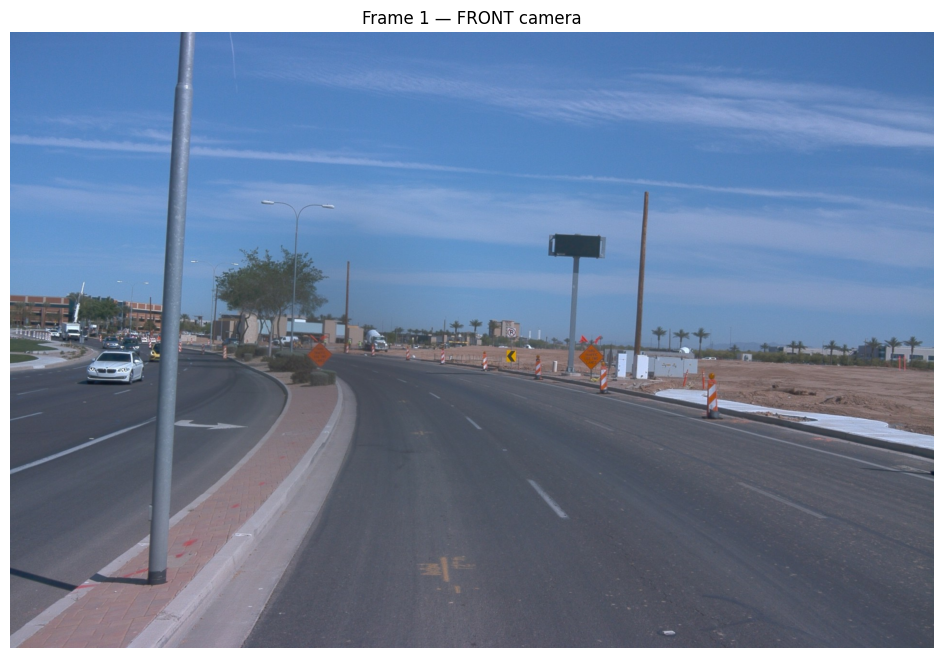

In [ ]:
import matplotlib.pyplot as plt
from waymo_open_dataset.utils import frame_utils
import tensorflow as tf

frame = frames[1]

# Camera name mapping (from the Waymo proto)
CAMERA_NAMES = {
    1: 'FRONT',
    2: 'FRONT_LEFT',
    3: 'FRONT_RIGHT',
    4: 'SIDE_LEFT',
    5: 'SIDE_RIGHT'
}

print(f"Cameras present: {[CAMERA_NAMES.get(img.name, img.name) for img in frame.images]}")

# Decode and show the FRONT camera image
for img in frame.images:
    if img.name == open_dataset.CameraName.FRONT:
        decoded = tf.image.decode_jpeg(img.image).numpy()
        plt.figure(figsize=(12, 8))
        plt.imshow(decoded)
        plt.title(f"Frame {frames.index(frame)} — FRONT camera")
        plt.axis('off')
        plt.show()
        break

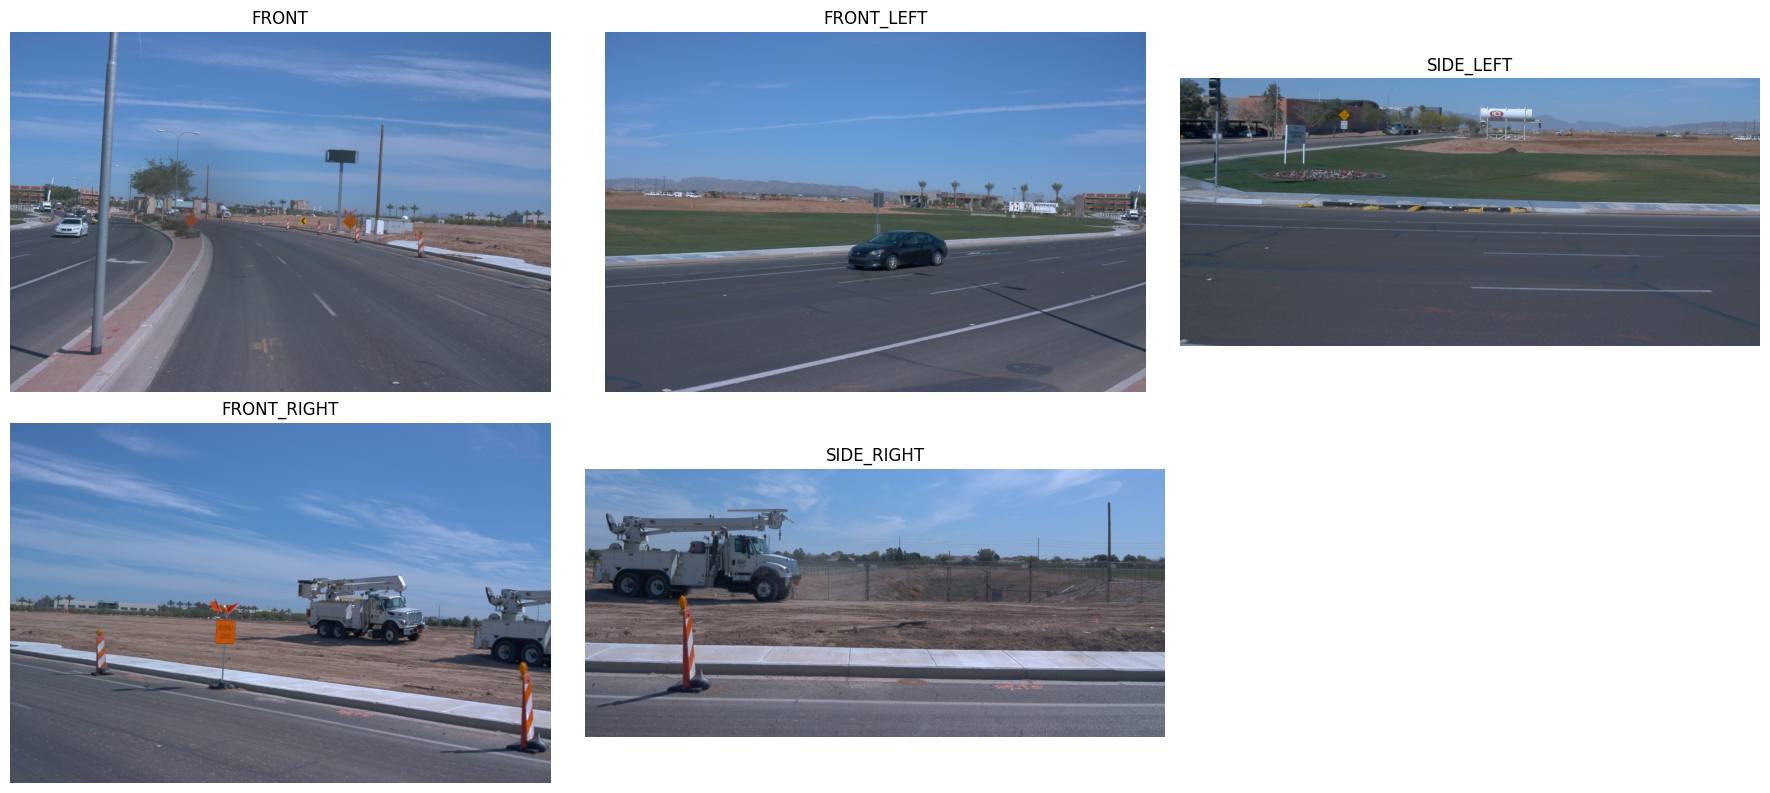

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, img in enumerate(frame.images):
    decoded = tf.image.decode_jpeg(img.image).numpy()
    axes[i].imshow(decoded)
    axes[i].set_title(CAMERA_NAMES.get(img.name, str(img.name)))
    axes[i].axis('off')

# Hide any unused subplot slots
for j in range(len(frame.images), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()